In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sorl.steer import StackedAbstractionWrapperV6, StackedAbstractionWrapperV9
from huggingface_hub import hf_hub_download, list_repo_files
import os, json
from data.pt_dataset import ScienceQADataset

# ---- Config ----
REPO = "Ksgk-fy/sciqa_ckpt_20260416_0942"

# RUN  = "q06_sciqa_v6_C32_base"        # change per run
RUN =  "q06_sciqa_v9_C32_detach_az0.1_aa0.5" # -> use "v9" to tell apart from v6
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model, tokenizer, args = load_steered_model(RUN, REPO, DEVICE)
val_ds = ScienceQADataset(split="test", tokenizer=tokenizer, max_length=512)

/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Mode: v9, Model: Qwen/Qwen3-0.6B
C=32, L=4, scale=0.5, layers=14


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loaded q06_sciqa_v9_C32_detach_az0.1_aa0.5 → StackedAbstractionWrapperV9 on cpu
  steering_emb: torch.Size([32, 1024])
  abs_proj: torch.Size([32, 1024])


In [ ]:
# Sanity check: batched accuracy evaluation on ScienceQA validation set | confirmed: accuracy is correct, loading is correct
from train_steer_pt import evaluate_accuracy

NUM_SAMPLES = 4       # cap for quick sanity check; set -1 for full set
EVAL_BATCH  = 4
MAX_NEW_TOK = 256

result = evaluate_accuracy(
    wrapper, tokenizer, val_ds, DEVICE,
    num_samples=NUM_SAMPLES,
    max_new_tokens=MAX_NEW_TOK,
    num_log_samples=3,
    eval_batch_size=EVAL_BATCH,
    log_fn=print,
)

print(f"\n{'='*60}")
print(f"Run: {RUN}")
print(f"Accuracy: {result['accuracy']*100:.2f}%  ({result['correct']}/{result['total']})")
print(f"{'='*60}")

# Show a few qualitative samples
for s in result.get("samples", [])[:3]:
    print(f"\n[{s['idx']}] gold={s['gold']!r}  pred={s['pred']!r}")
    print(f"   Q: {s['question'][:150]}")
    print(f"   A: {s['response'][:200]}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



  Accuracy: 3/4 = 75.0%

--- Sample 0 ---
  Q: Question: Which figure of speech is used in this text?
Sing, O goddess, the anger of Achilles son of Peleus, that brought countless ills upon the Achaeans.
—Homer, The Iliad
A) chiasmus
B) apostrophe
Answer:
  Response: Figures of speech are words or phrases that use language in a nonliteral or unusual way. They can make writing more expressive.
Anaphora is the repetition of the same word or words at the beginning of several phrases or clauses.
We are united. We are powerful. We are winners.
Antithesis involves contrasting opposing ideas within a parallel grammatical structure.
I want to help, not to hurt.
Apostrophe is a direct address to an absent person or a nonhuman entity.
Oh, little bird, what makes you sing so beautifully?
Assonance is the repetition of a vowel sound in a series of nearby words.
Try to light the fire.
Chiasmus is an expression in which the second half parallels the first but reverses the order of words.
Never let a

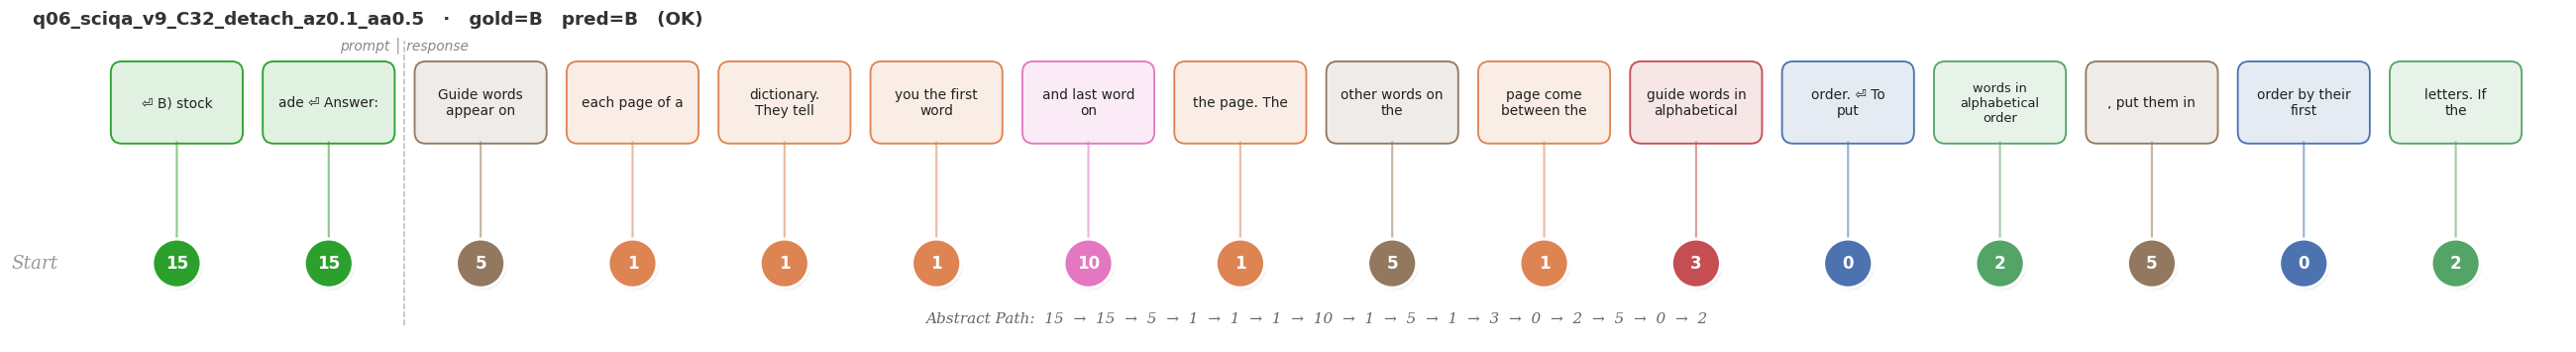

In [ ]:
# Visualize any sample from the evaluate_accuracy result
from sorl.analyze import visualize_inner_monologue

idx = 2
sample = result["samples"][idx]
code   = result["codes"][idx]
L      = code["L"]

n_prompt_chunks = len(code["prompt"])

fig = visualize_inner_monologue(
    sample, tokenizer, L=L, code=code,
    start_chunk=max(0, n_prompt_chunks - 2),   # jump near the prompt/response boundary
    max_chunks=16,
    title=f"{RUN}   ·   gold={sample['gold']}   pred={sample['pred']}   "
          f"({'OK' if sample['correct'] else 'WRONG'})",
)
plt.show()


In [9]:
# Verify steering affects decoding: compare generations across scales
import torch

sample = val_ds[0]
pl = sample["prompt_len"]
prompt_ids = sample["input_ids"][:pl].unsqueeze(0).to(DEVICE)
attn = torch.ones_like(prompt_ids)

SCALES        = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5]
MAX_NEW       = 48

prompt_text = tokenizer.decode(prompt_ids[0], skip_special_tokens=True)
print(f"--- prompt ---\n{prompt_text}\n")

orig_scale = wrapper.scale
try:
    for s in SCALES:
        wrapper.scale = float(s)
        with torch.no_grad():
            out = wrapper.generate(
                input_ids=prompt_ids,
                attention_mask=attn,
                max_new_tokens=MAX_NEW,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                log_decode_codes=True,
            )
        gen_text  = tokenizer.decode(out[0, pl:], skip_special_tokens=True)
        gen_codes = [c[0].item() for c in wrapper._decode_codes_log]

        print(f"=== scale = {s} ===")
        print(f"  decode codes ({len(gen_codes)}): {gen_codes}")
        print(f"  text: {gen_text!r}\n")
finally:
    wrapper.scale = orig_scale

--- prompt ---
Question: Which figure of speech is used in this text?
Sing, O goddess, the anger of Achilles son of Peleus, that brought countless ills upon the Achaeans.
—Homer, The Iliad
A) chiasmus
B) apostrophe
Answer:

=== scale = 0.0 ===
  decode codes (12): [5, 1, 1, 3, 0, 2, 5, 1, 1, 2, 1, 5]
  text: ' Figures of speech are words or phrases that use language in a nonliteral or unusual way. They can make writing more expressive.\nAnaphora is the repetition of the same word or words at the beginning of several phrases or clauses.\nWe are'

=== scale = 0.25 ===
  decode codes (12): [5, 1, 1, 3, 0, 2, 5, 1, 1, 2, 1, 5]
  text: ' Figures of speech are words or phrases that use language in a nonliteral or unusual way. They can make writing more expressive.\nAnaphora is the repetition of the same word or words at the beginning of several phrases or clauses.\nWe are'

=== scale = 0.5 ===
  decode codes (12): [5, 1, 1, 3, 0, 2, 5, 1, 1, 2, 1, 5]
  text: ' Figures of speech are words or 

In [ ]:
# (I). Avg cosine similarity between different steering vectors
import torch.nn.functional as F
 
w = wrapper.steering_emb.weight  # (C_SIZE, D_MODEL)
w_norm = F.normalize(w, dim=-1)
cos_sim = w_norm @ w_norm.T  # (C_SIZE, C_SIZE)
 
# Mask out diagonal (self-similarity = 1.0) and average upper triangle
mask = torch.triu(torch.ones_like(cos_sim, dtype=torch.bool), diagonal=1)
avg_cos = cos_sim[mask].mean().item()
print(f"Avg pairwise cosine similarity: {avg_cos:.4f}")

In [52]:
# Collect inner-monologue codes + sequence-level representations
# For each sequence, store:
#   - codes: chunk-level abstraction codes (one per L-token window)
#   - inject_repr[layer]: mean-pooled hidden state at each inject layer (post-steering)
#   - last_repr: mean-pooled hidden state at the final transformer layer
#   - inject_last[layer], last_last: last-token hidden state (useful for next-token analysis)
from tqdm.auto import tqdm
from data.pt_dataset import ScienceQADataset
import torch.nn.functional as F

# ---- Load eval dataset ----
val_ds = ScienceQADataset(split="test", tokenizer=tokenizer, max_length=512)

NUM_COLLECT = 100   # set -1 for full test set

n_layers_total = len(wrapper.model.model.layers)
last_layer_idx = n_layers_total - 1
inject_layer_ids = list(wrapper.inject_layers)
print(f"Inject layers: {inject_layer_ids}  |  Last layer: {last_layer_idx}  |  L={wrapper.L}")

# ---- Temporary hooks to capture hidden states ----
_captured = {}

def _make_capture_hook(name):
    def hook(module, inp, out):
        h = out[0] if isinstance(out, tuple) else out
        _captured[name] = h.detach()
    return hook

capture_hooks = []
for li in inject_layer_ids:
    h = wrapper.model.model.layers[li].register_forward_hook(
        _make_capture_hook(f"inject_{li}"))
    capture_hooks.append(h)
h = wrapper.model.model.layers[last_layer_idx].register_forward_hook(
    _make_capture_hook("last"))
capture_hooks.append(h)

# ---- Collect ----
n = len(val_ds) if NUM_COLLECT <= 0 else min(NUM_COLLECT, len(val_ds))
records = []

wrapper.eval()
try:
    for i in tqdm(range(n), desc="Collecting"):
        sample = val_ds[i]
        input_ids = sample["input_ids"].unsqueeze(0).to(DEVICE)
        attn_mask = sample["attention_mask"].unsqueeze(0).to(DEVICE)
        prompt_len = sample["prompt_len"]

        with torch.no_grad():
            _ = wrapper(input_ids=input_ids, attention_mask=attn_mask)

        # Normalize code storage: V6 stores (B, S) = per-token, V9 stores (B, n_chunks) = per-chunk
        codes_full = wrapper._last_codes[0]              # (S,) or (n_chunks,)
        S = input_ids.shape[1]
        if codes_full.shape[0] == S:                     # V6: stride by L to get per-chunk
            chunk_codes = codes_full[::wrapper.L].cpu()
        else:                                             # V9: already per-chunk
            chunk_codes = codes_full.cpu()

        # Pool representations
        mask = attn_mask[0].float().unsqueeze(-1)        # (S, 1)
        valid_tokens = mask.sum().clamp(min=1)

        rec = {
            "idx": i,
            "prompt_len": prompt_len,
            "seq_len": int(valid_tokens.item()),
            "codes": chunk_codes,                         # chunk-level codes
            "inject_repr": {},                            # mean-pool at inject layers
            "inject_last": {},                            # last-token at inject layers
        }
        for li in inject_layer_ids:
            h = _captured[f"inject_{li}"][0]              # (S, D)
            rec["inject_repr"][li] = ((h * mask).sum(0) / valid_tokens).cpu()
            rec["inject_last"][li] = h[int(valid_tokens.item()) - 1].cpu()

        h_last = _captured["last"][0]                     # (S, D)
        rec["last_repr"] = ((h_last * mask).sum(0) / valid_tokens).cpu()
        rec["last_last"] = h_last[int(valid_tokens.item()) - 1].cpu()

        # Metadata for later qualitative analysis
        ex = val_ds.dataset[i]
        p, t = ScienceQADataset.parse_sample(ex)
        rec["prompt"] = p
        rec["answer_text"] = t[len(p):].strip()
        rec["gold_letter"] = chr(ord("A") + ex["answer"])

        records.append(rec)
finally:
    for h in capture_hooks:
        h.remove()

# ---- Summary ----
print(f"\nCollected {len(records)} records.")
print(f"Example record[0] keys: {list(records[0].keys())}")
print(f"  codes shape: {records[0]['codes'].shape}  (first 16: {records[0]['codes'][:16].tolist()})")
print(f"  inject_repr[{inject_layer_ids[0]}] shape: {records[0]['inject_repr'][inject_layer_ids[0]].shape}")
print(f"  last_repr shape: {records[0]['last_repr'].shape}")

# ---- Persist for downstream analysis ----
os.makedirs("./analysis_out", exist_ok=True)
save_path = f"./analysis_out/{RUN}_inner_monologue.pt"
torch.save({
    "run": RUN,
    "args": args,
    "inject_layers": inject_layer_ids,
    "last_layer": last_layer_idx,
    "L": wrapper.L,
    "C_SIZE": wrapper.C_SIZE,
    "records": records,
}, save_path)
print(f"\nSaved to {save_path}")

Inject layers: [14]  |  Last layer: 27  |  L=4


Collecting:   0%|          | 0/100 [00:00<?, ?it/s]


Collected 100 records.
Example record[0] keys: ['idx', 'prompt_len', 'seq_len', 'codes', 'inject_repr', 'inject_last', 'last_repr', 'last_last', 'prompt', 'answer_text', 'gold_letter']
  codes shape: torch.Size([128])  (first 16: [0, 2, 1, 1, 1, 4, 0, 0, 0, 4, 4, 4, 5, 15, 4, 5])
  inject_repr[14] shape: torch.Size([1024])
  last_repr shape: torch.Size([1024])

Saved to ./analysis_out/q06_sciqa_v9_C32_detach_az0.1_aa0.5_inner_monologue.pt


In [54]:
# How big is the steering signal relative to the hidden state it is added to?
#   effective added vector = steering_emb[code] * wrapper.scale
#   what we care about     = ||effective|| / ||h||  at the inject layer
import numpy as np, torch

LAYER   = wrapper.inject_layers[0]
N_EX    = 32
SKIP    = 4                                # drop BOS-ish outliers

# ---- 1. steering-embedding norms ----------------------------------
with torch.no_grad():
    emb = wrapper.steering_emb.weight.detach().float().cpu().numpy()   # (C, D)
emb_norms = np.linalg.norm(emb, axis=1)                                # (C,)
scale = float(wrapper.scale)
eff_norms = emb_norms * scale                                          # actually added

print(f"steering embedding (C={emb.shape[0]}, D={emb.shape[1]}):")
print(f"  ||emb[k]||           mean={emb_norms.mean():.3f}  "
      f"median={np.median(emb_norms):.3f}  min={emb_norms.min():.3f}  "
      f"max={emb_norms.max():.3f}")
print(f"  scale                {scale}")
print(f"  ||emb[k]||*scale     mean={eff_norms.mean():.3f}  "
      f"median={np.median(eff_norms):.3f}  "
      f"max={eff_norms.max():.3f}")


# ---- 2. hidden-state norms at the inject layer (no steering) -------
cap = {}
def _hook(_, __, out):
    cap["h"] = (out[0] if isinstance(out, tuple) else out).detach()
h = wrapper.model.model.layers[LAYER].register_forward_hook(_hook)

orig_scale = wrapper.scale
wrapper.scale = 0.0          # measure the unsteered hidden state
h_norms = []
try:
    for i in range(min(N_EX, len(val_ds))):
        s = val_ds[i]
        ii = s["input_ids"].unsqueeze(0).to(DEVICE)
        am = s["attention_mask"].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            _ = wrapper(input_ids=ii, attention_mask=am)
        S = int(am[0].sum().item())
        hn = cap["h"][0, SKIP:S].float().cpu().numpy()
        h_norms.append(np.linalg.norm(hn, axis=1))
finally:
    wrapper.scale = orig_scale
    h.remove()

h_norms = np.concatenate(h_norms)

print(f"\nhidden-state ||h|| at layer {LAYER} "
      f"(skipping first {SKIP}, across {N_EX} seqs):")
print(f"  mean={h_norms.mean():.3f}  median={np.median(h_norms):.3f}  "
      f"5/95 pct=({np.percentile(h_norms,5):.3f}, "
      f"{np.percentile(h_norms,95):.3f})")


# ---- 3. the ratio (what matters) ----------------------------------
ratio_mean = eff_norms.mean() / h_norms.mean()
ratio_max  = eff_norms.max()  / h_norms.mean()
print(f"\n--- relative magnitude of steering perturbation ---")
print(f"  mean ||Δh_steer|| / mean ||h||  =  {ratio_mean*100:.2f}%")
print(f"  max  ||Δh_steer|| / mean ||h||  =  {ratio_max*100:.2f}%")
if ratio_mean < 0.02:
    print("  → steering is <2% of ||h||; visual effects will be tiny.")
    print("    try increasing wrapper.scale, or steering more layers.")


steering embedding (C=32, D=1024):
  ||emb[k]||           mean=10.909  median=4.025  min=1.045  max=57.246
  scale                0.5
  ||emb[k]||*scale     mean=5.455  median=2.012  max=28.623

hidden-state ||h|| at layer 14 (skipping first 4, across 32 seqs):
  mean=49.797  median=49.728  5/95 pct=(40.917, 58.737)

--- relative magnitude of steering perturbation ---
  mean ||Δh_steer|| / mean ||h||  =  10.95%
  max  ||Δh_steer|| / mean ||h||  =  57.48%


Δh_steer shape = (32, 119, 1024)   ||Δ|| mean=10.155
PCA(Δ) explained variance (2D): 15.46%  (per-axis: [0.0860000029206276, 0.06800000369548798])


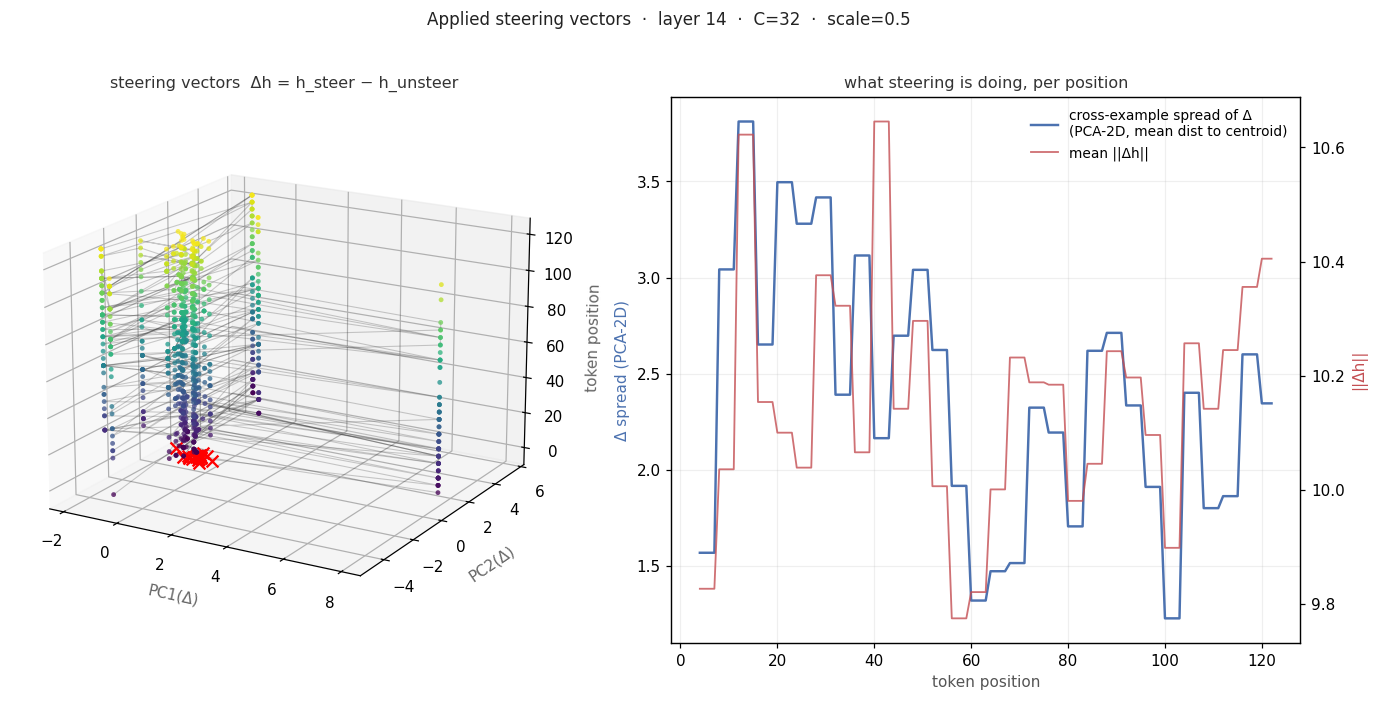

In [55]:
# 3D PCA of the APPLIED steering vectors only
#   Δh_steer[i, t]  =  h_steered[i, t]  -  h_unsteered[i, t]
# This isolates the perturbation that was actually injected, stripped of the
# base residual stream. Spread here = diversity of what steering is *doing*.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

# Reuse the collected reps from the earlier cell (X_s, X_b, z_abs, ts, T, N).
# X_s and X_b are (N, T, D) and already have SKIP_FIRST tokens dropped.
Delta = X_s - X_b                                 # (N, T, D)
print(f"Δh_steer shape = {Delta.shape}   "
      f"||Δ|| mean={np.linalg.norm(Delta, axis=-1).mean():.3f}")

# PCA fit on the pool of perturbation vectors across all (i, t)
Dflat = Delta.reshape(-1, Delta.shape[-1])
pca_d = PCA(n_components=2).fit(Dflat)
Pd    = pca_d.transform(Dflat).reshape(N, T, 2)
print(f"PCA(Δ) explained variance (2D): "
      f"{pca_d.explained_variance_ratio_.sum():.2%}  "
      f"(per-axis: {pca_d.explained_variance_ratio_.round(3).tolist()})")

# Outlier-clipped axis limits
lo_d = np.percentile(Pd.reshape(-1, 2), 100 - CLIP_PCT, axis=0)
hi_d = np.percentile(Pd.reshape(-1, 2), CLIP_PCT,       axis=0)
xlim_d, ylim_d = (lo_d[0], hi_d[0]), (lo_d[1], hi_d[1])

# ---- plot ----------------------------------------------------------------
fig = plt.figure(figsize=(13, 6.2), dpi=110)
fig.patch.set_facecolor("white")

# (left)  3D stack: token position = z, PCA-2D of Δh on each slab
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
for t in ts:
    ax3d.scatter(Pd[:, t, 0], Pd[:, t, 1],
                 np.full(N, z_abs[t]),
                 c=np.full(N, t), cmap="viridis", vmin=0, vmax=T - 1,
                 s=10, alpha=0.75, linewidth=0, depthshade=False)
for i in range(min(N, 10)):
    ax3d.plot(Pd[i, ts, 0], Pd[i, ts, 1], z_abs[ts],
              color="#333", alpha=0.25, linewidth=0.7)

# Overlay the projected code embeddings as large markers
emb_s   = wrapper.scale * wrapper.steering_emb.weight.detach().float().cpu().numpy()
emb_pca = pca_d.transform(emb_s)                  # (C, 2)
ax3d.scatter(emb_pca[:, 0], emb_pca[:, 1],
             np.full(len(emb_pca), z_abs[0] - 5),   # anchor below the stack
             c="red", marker="x", s=60, depthshade=False)
             
ax3d.set_xlim(*xlim_d); ax3d.set_ylim(*ylim_d)
ax3d.set_xlabel("PC1(Δ)", color="#666", labelpad=6)
ax3d.set_ylabel("PC2(Δ)", color="#666", labelpad=6)
ax3d.set_zlabel("token position", color="#666", labelpad=6)
ax3d.set_title("steering vectors  Δh = h_steer − h_unsteer",
               fontsize=10.5, color="#333")
ax3d.view_init(elev=18, azim=-60)

# (right) cross-example spread of Δ at each token position
mu_d       = Pd.mean(axis=0, keepdims=True)
spread_d   = np.linalg.norm(Pd - mu_d, axis=-1).mean(axis=0)         # (T,)
# also: did the *code itself* change across examples at each position?
norm_d     = np.linalg.norm(Delta, axis=-1).mean(axis=0)             # (T,)

ax1 = fig.add_subplot(1, 2, 2)
ax1.plot(z_abs, spread_d, color="#4C72B0", lw=1.6,
         label="cross-example spread of Δ\n(PCA-2D, mean dist to centroid)")
ax1b = ax1.twinx()
ax1b.plot(z_abs, norm_d, color="#C44E52", lw=1.2, alpha=0.8,
          label="mean ||Δh||")
ax1.set_xlabel("token position", color="#555")
ax1.set_ylabel("Δ spread (PCA-2D)", color="#4C72B0")
ax1b.set_ylabel("||Δh||", color="#C44E52")
ax1.grid(alpha=0.2)
lns  = ax1.get_lines() + ax1b.get_lines()
ax1.legend(lns, [l.get_label() for l in lns],
           frameon=False, loc="upper right", fontsize=9)
ax1.set_title("what steering is doing, per position",
              fontsize=10.5, color="#333")

fig.suptitle(
    f"Applied steering vectors  ·  layer {PROBE_LAYER_3D}  ·  "
    f"C={wrapper.steering_emb.num_embeddings}  ·  scale={wrapper.scale}",
    fontsize=11, color="#222", y=1.02,
)
plt.tight_layout()
plt.show()


In [40]:
# (2). Load the inner-monologue codes produced by eval_decode_scale.py
# File schema: {samples: [{idx, question, response, gold, pred, correct}],
#               codes:   [{prompt: [int], response: [int], L, pad_prefix_chunks}]}
import torch

l1b_pt_file = "log/analysis_out/decode_scale_sweep_1452/l1_sciqa_v9_C32_detach_az0.1_aa0.1__ps0.100_respprompt.pt"

blob = torch.load(l1b_pt_file, map_location="cpu", weights_only=False)
samples = blob["samples"]
codes   = blob["codes"]
L       = blob["L"]
C_SIZE  = blob["C_SIZE"]

assert len(samples) == len(codes), (len(samples), len(codes))
print(f"run={blob['run']}  mode={blob['mode']}  "
      f"trained_scale={blob['trained_scale']}  prompt_scale={blob['prompt_scale']}  "
      f"cond={blob['condition']}  acc={blob['accuracy']*100:.2f}%")
print(f"samples={len(samples)}  C={C_SIZE}  L={L}")

# peek at one
s0, c0 = samples[0], codes[0]
print(f"\nsample[0] keys: {list(s0.keys())}")
print(f"  idx={s0['idx']}  gold={s0['gold']}  pred={s0['pred']}  correct={s0['correct']}")
print(f"code[0] keys: {list(c0.keys())}  "
      f"|prompt|={len(c0['prompt'])}  |response|={len(c0['response'])}")
print(f"  prompt codes (first 16): {c0['prompt'][:16]}")
print(f"  response codes (first 16): {c0['response'][:16]}")


run=l1_sciqa_v9_C32_detach_az0.1_aa0.1  mode=v9  trained_scale=0.1  prompt_scale=0.1  cond=resp=prompt  acc=53.05%
samples=2000  C=32  L=4

sample[0] keys: ['idx', 'question', 'response', 'gold', 'pred', 'correct']
  idx=0  gold=B  pred=B  correct=True
code[0] keys: ['prompt', 'response', 'L', 'pad_prefix_chunks']  |prompt|=16  |response|=63
  prompt codes (first 16): [4, 3, 0, 1, 5, 9, 2, 1, 5, 4, 4, 12, 1, 7, 13, 6]
  response codes (first 16): [3, 16, 0, 2, 12, 0, 3, 17, 6, 0, 1, 16, 3, 3, 1, 8]


In [63]:
# (3). Group inner-monologues by {correctness, topic, grade, subject} and
# measure within- vs between-group distance under two complementary metrics:
#   - edit : normalized Levenshtein on response-code sequences  (structure)
#   - hist : total-variation L1 on response-code histograms     (word usage)
#
#   pip install rapidfuzz
import numpy as np
from collections import defaultdict
from scipy.spatial.distance import cdist as sp_cdist
from rapidfuzz.distance import Levenshtein
from rapidfuzz.process import cdist as rf_cdist

# --- metadata ---------------------------------------------------------------
meta = []
for s in samples:
    ex = val_ds.dataset[s["idx"]]
    meta.append({
        "correct": bool(s["correct"]),
        "subject": ex["subject"],
        "topic":   ex["topic"],
        "grade":   ex["grade"],
    })

# --- response-code sequences ------------------------------------------------
seqs = [c["response"] for c in codes]
valid_mask = np.array([bool(c["prompt"]) and bool(c["response"]) for c in codes])
valid_idx  = np.where(valid_mask)[0]
print(f"Valid samples: {len(valid_idx)}/{len(codes)}")

# --- distance matrices ------------------------------------------------------
# edit: rapidfuzz on string-encoded sequences (C <= 32 -> printable ASCII).
def _to_str(seq):  return "".join(chr(32 + c) for c in seq)
sub_str = [_to_str(seqs[i]) for i in valid_idx]
print(f"  cdist edit/response on {len(sub_str)} seqs ...", end="", flush=True)
D_EDIT = rf_cdist(sub_str, sub_str,
                  scorer=Levenshtein.normalized_distance, workers=-1)
print(" done")

# hist: code-frequency distribution -> 0.5 * L1 = total variation in [0, 1].
H = np.zeros((len(valid_idx), C_SIZE), dtype=np.float64)
for row, i in enumerate(valid_idx):
    if seqs[i]:
        np.add.at(H[row], seqs[i], 1.0)
        H[row] /= H[row].sum()
print(f"  cdist hist/response on {H.shape[0]} hists ...", end="", flush=True)
D_HIST = 0.5 * sp_cdist(H, H, metric="cityblock")
print(" done")

DMATS = {"edit": D_EDIT, "hist": D_HIST}
pos = {orig: i for i, orig in enumerate(valid_idx.tolist())}

# --- group analyzer ---------------------------------------------------------
def analyze_grouping(label_fn, name, min_size=20, top_groups=None):
    all_groups = defaultdict(list)
    for i in valid_idx.tolist():
        lbl = label_fn(meta[i])
        if lbl is None: continue
        all_groups[lbl].append(pos[i])

    all_groups = {k: v for k, v in all_groups.items() if len(v) >= min_size}
    if top_groups is not None:
        all_groups = dict(sorted(all_groups.items(),
                                 key=lambda kv: -len(kv[1]))[:top_groups])
    labels = sorted(all_groups.keys(), key=lambda k: -len(all_groups[k]))
    if len(labels) < 2:
        print(f"[{name}] <2 groups with ≥{min_size} members — skipping.")
        return

    print(f"\n=== Grouping by {name}  ({len(labels)} groups, n/group ≥{min_size}) ===")
    for metric, D in DMATS.items():
        within, between = {}, {}
        for a in labels:
            ids = np.asarray(all_groups[a])
            sub = D[np.ix_(ids, ids)]
            iu = np.triu_indices(len(ids), k=1)
            within[a] = float(sub[iu].mean()) if iu[0].size else float("nan")
            other = np.concatenate([np.asarray(all_groups[b])
                                    for b in labels if b != a])
            between[a] = float(D[np.ix_(ids, other)].mean())

        print(f"\n  [{metric}/response]  {'group':<28s} {'n':>4s} {'within':>8s} {'between':>9s} {'gap':>8s}")
        print("  " + "-" * 68)
        for a in sorted(labels, key=lambda a: between[a] - within[a], reverse=True):
            g = between[a] - within[a]
            print(f"     {str(a):<28s} {len(all_groups[a]):>4d} "
                  f"{within[a]:>8.3f} {between[a]:>9.3f} {g:>+8.3f}")
        W = float(np.mean(list(within.values())))
        B = float(np.mean(list(between.values())))
        print(f"     {'(macro avg)':<28s} {'':>4s} {W:>8.3f} {B:>9.3f} {B - W:>+8.3f}")

# --- run --------------------------------------------------------------------
# analyze_grouping(lambda m: "correct" if m["correct"] else "wrong",
                #  name="correctness", min_size=50)
analyze_grouping(lambda m: m["topic"],   name="topic", min_size=30)
# analyze_grouping(lambda m: m["grade"],   name="grade", min_size=50)
# analyze_grouping(lambda m: m["subject"], name="subject", min_size=50)


Valid samples: 2000/2000
  cdist edit/response on 2000 seqs ... done
  cdist hist/response on 2000 hists ... done

=== Grouping by topic  (13 groups, n/group ≥30) ===

  [edit/response]  group                           n   within   between      gap
  --------------------------------------------------------------------
     science-and-engineering-practices   56    0.556     0.819   +0.264
     verbs                          49    0.562     0.785   +0.223
     reference-skills              136    0.623     0.789   +0.167
     grammar                        62    0.656     0.789   +0.133
     units-and-measurement         189    0.723     0.800   +0.077
     punctuation                    92    0.724     0.793   +0.069
     chemistry                     107    0.733     0.800   +0.068
     economics                      76    0.769     0.815   +0.046
     figurative-language           241    0.761     0.799   +0.038
     biology                       345    0.764     0.797   +0.033
     

Topics (13, n ≥ 30): ordered by within-topic edit distance


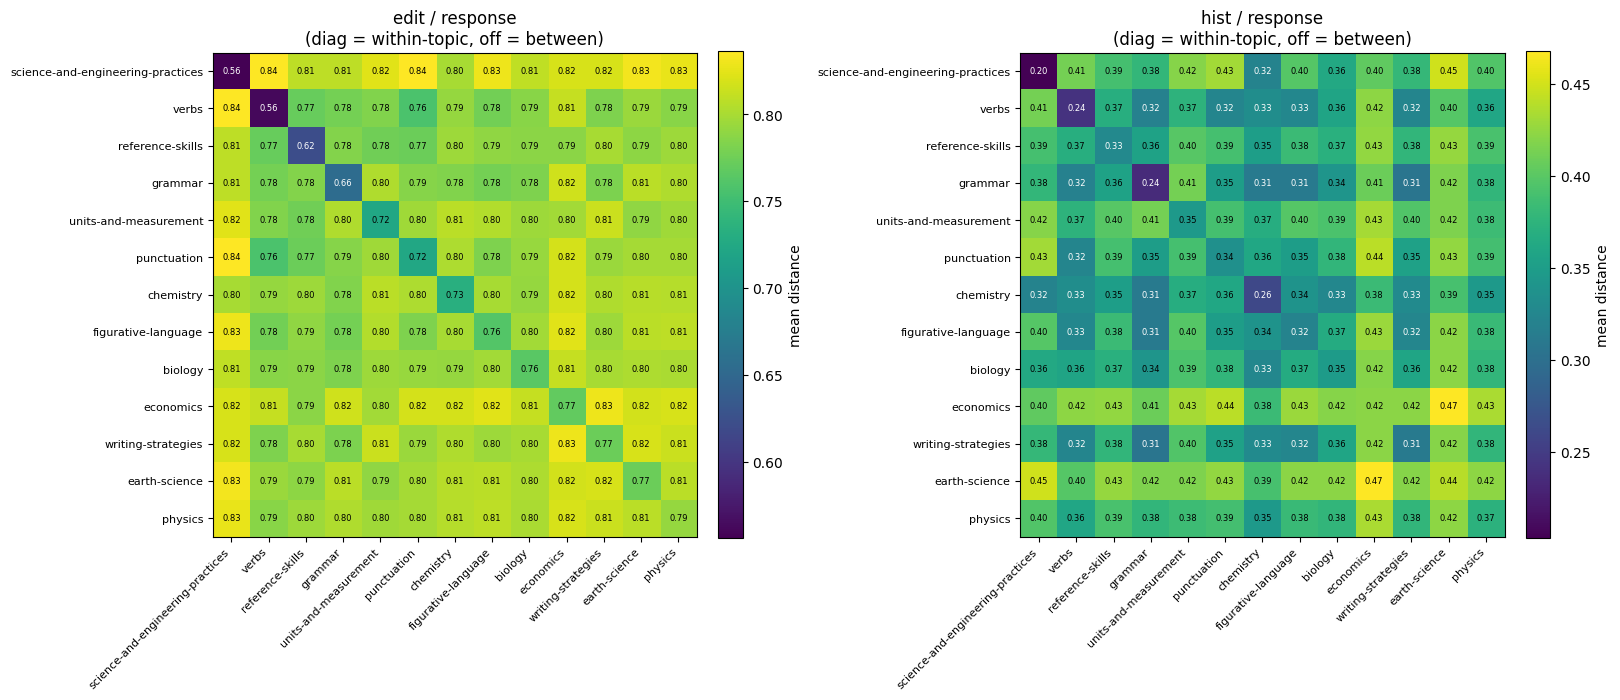

In [66]:
# (4). Cross-topic distance heatmaps — for each metric, build a (T, T) matrix
# where cell [i, j] = mean distance between every response-code pair drawn
# from topic i and topic j.  Diagonal = within-topic, off-diagonal = between.
import numpy as np
import matplotlib.pyplot as plt

MIN_SIZE = 30
groups = defaultdict(list)   # topic -> row indices into DMATS
for i in valid_idx.tolist():
    groups[meta[i]["topic"]].append(pos[i])
groups = {k: v for k, v in groups.items() if len(v) >= MIN_SIZE}
# order topics by within-topic distance (smallest = most internally consistent)
def _within_edit(k):
    ids = np.asarray(groups[k])
    iu = np.triu_indices(len(ids), k=1)
    return D_EDIT[np.ix_(ids, ids)][iu].mean()
labels = sorted(groups.keys(), key=_within_edit)
T = len(labels)
print(f"Topics ({T}, n ≥ {MIN_SIZE}): ordered by within-topic edit distance")

def pair_matrix(D):
    M = np.zeros((T, T))
    for i, a in enumerate(labels):
        ids_a = np.asarray(groups[a])
        for j, b in enumerate(labels):
            ids_b = np.asarray(groups[b])
            if i == j:
                iu = np.triu_indices(len(ids_a), k=1)
                M[i, j] = D[np.ix_(ids_a, ids_a)][iu].mean()
            else:
                M[i, j] = D[np.ix_(ids_a, ids_b)].mean()
    return M

M_edit = pair_matrix(D_EDIT)
M_hist = pair_matrix(D_HIST)

fig, axes = plt.subplots(1, 2, figsize=(2 + 0.55 * T * 2, 0.55 * T + 2))
for ax, M, title in [(axes[0], M_edit, "edit / response"),
                     (axes[1], M_hist, "hist / response")]:
    im = ax.imshow(M, cmap="viridis",
                   vmin=np.nanmin(M), vmax=np.nanmax(M))
    ax.set_xticks(range(T)); ax.set_yticks(range(T))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    thresh = (np.nanmax(M) + np.nanmin(M)) / 2
    for i in range(T):
        for j in range(T):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                    fontsize=6, color="white" if M[i, j] < thresh else "black")
    ax.set_title(f"{title}\n(diag = within-topic, off = between)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="mean distance")

# fig.suptitle(f"Cross-topic response-code distance  ({blob['run']}, "
#              f"ps={blob['prompt_scale']}, cond={blob['condition']})",
#              fontsize=11)
plt.tight_layout()
plt.show()


Building baseline distance matrices ...
  [real         ]  mean=0.370  std=0.104  std/mean=0.282
  [uniform      ]  mean=0.378  std=0.053  std/mean=0.140
  [freq-matched ]  mean=0.293  std=0.054  std/mean=0.184

=== real codes ===
  [real         ]  K=  4  AMI=0.151  p@1=27.5%  lift=1.50x
  [real         ]  K=  8  AMI=0.169  p@1=27.6%  lift=1.50x
  [real         ]  K= 13  AMI=0.222  p@1=34.5%  lift=1.88x
  [real         ]  K= 20  AMI=0.257  p@1=41.5%  lift=2.26x
  [real         ]  K= 30  AMI=0.288  p@1=44.6%  lift=2.43x
  [real         ]  K= 40  AMI=0.296  p@1=47.5%  lift=2.59x
  [real         ]  K= 50  AMI=0.308  p@1=49.9%  lift=2.72x
  [real         ]  K= 60  AMI=0.300  p@1=51.4%  lift=2.80x
  [real         ]  K= 70  AMI=0.285  p@1=51.3%  lift=2.79x
  [real         ]  K= 80  AMI=0.281  p@1=50.2%  lift=2.74x
  [real         ]  K=120  AMI=0.241  p@1=51.0%  lift=2.78x

=== uniform random codes ===
  [uniform      ]  K=  4  AMI=-0.002  p@1=18.4%  lift=1.00x
  [uniform      ]  K=  8  AMI=

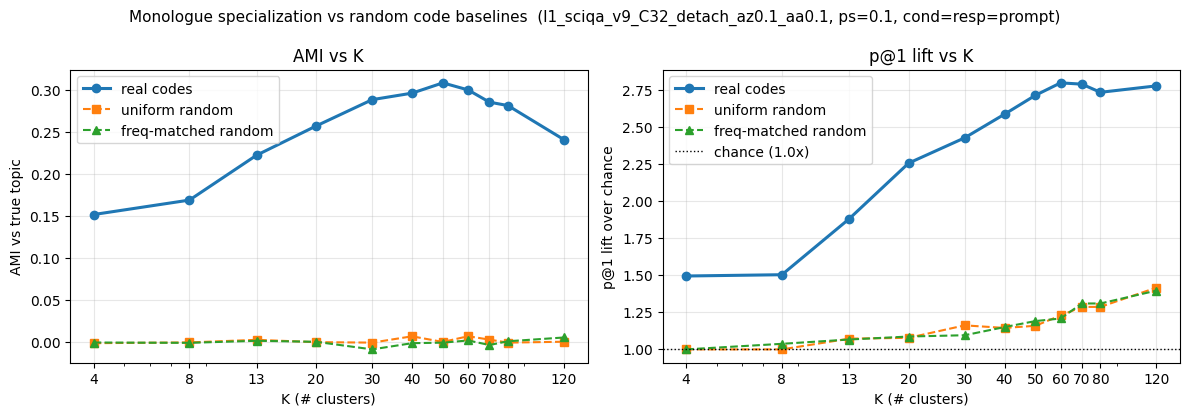

In [91]:
# (6). Baseline comparison: K-sweep of AMI for REAL monologue codes vs
# two random-code baselines:
#   (a) uniform      -- codes drawn iid uniform over codebook, matching length
#   (b) freq-matched -- codes drawn iid from the global marginal code frequency
# Both preserve the per-sample sequence *length* distribution but destroy any
# per-sample structure.  Real > baselines -> specialization is in the code
# IDENTITIES assigned per sample, not in trivial statistics of the codebook.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_mutual_info_score
from scipy.spatial.distance import cdist as sp_cdist

K_SWEEP = [4, 8, 13, 20, 30, 40, 50, 60, 70, 80, 120]
RNG = np.random.default_rng(0)

# --- build random code sequences with matched lengths ----------------------
real_seqs = [codes[i]["response"] for i in valid_idx.tolist()]
lens = [len(s) for s in real_seqs]

uniform_seqs = [RNG.integers(0, C_SIZE, size=L).tolist() for L in lens]

all_codes = np.concatenate([np.asarray(s) for s in real_seqs if len(s)])
marginal  = np.bincount(all_codes, minlength=C_SIZE).astype(float)
marginal /= marginal.sum()
freq_seqs = [RNG.choice(C_SIZE, size=L, p=marginal).tolist() for L in lens]

def seqs_to_hist_dist(seqs):
    H = np.zeros((len(seqs), C_SIZE), dtype=np.float64)
    for i, s in enumerate(seqs):
        if s:
            np.add.at(H[i], s, 1.0)
            H[i] /= H[i].sum()
    return 0.5 * sp_cdist(H, H, metric="cityblock")

print("Building baseline distance matrices ...")
D_real_sub = D_HIST[np.ix_(sub_pos, sub_pos)]
D_uni_sub  = seqs_to_hist_dist(uniform_seqs)[np.ix_(sub_pos, sub_pos)]
D_freq_sub = seqs_to_hist_dist(freq_seqs)[np.ix_(sub_pos, sub_pos)]

for tag, D in [("real", D_real_sub), ("uniform", D_uni_sub),
               ("freq-matched", D_freq_sub)]:
    off = D[np.triu_indices(len(sub_pos), k=1)]
    print(f"  [{tag:<13s}]  mean={off.mean():.3f}  std={off.std():.3f}  "
          f"std/mean={off.std()/off.mean():.3f}")

# --- K-sweep ---------------------------------------------------------------
topic_idx_map = {t: j for j, t in enumerate(keep_topics)}
chance_p1 = BASELINE_PK[1]

def sweep(D_in, tag):
    D = 0.5 * (D_in + D_in.T); np.fill_diagonal(D, 0.0)
    sigma = np.median(D[D > 0])
    A = np.exp(-(D ** 2) / (2.0 * sigma ** 2)); np.fill_diagonal(A, 1.0)
    amis, lifts = [], []
    for K_ in K_SWEEP:
        cl = SpectralClustering(n_clusters=K_, affinity="precomputed",
                                assign_labels="kmeans", random_state=0,
                                n_init=10).fit(A)
        lbl = cl.labels_
        ami = adjusted_mutual_info_score(sub_topic, lbl)
        M = np.zeros((K_, T), dtype=int)
        for c, t in zip(lbl, sub_topic):
            M[c, topic_idx_map[t]] += 1
        p1 = sum(M[r].max() for r in range(K_)) / M.sum()
        amis.append(ami); lifts.append(p1 / chance_p1)
        print(f"  [{tag:<13s}]  K={K_:>3d}  AMI={ami:.3f}  "
              f"p@1={p1*100:>4.1f}%  lift={p1/chance_p1:.2f}x")
    return np.array(amis), np.array(lifts)

print("\n=== real codes ===")
ami_r, lift_r = sweep(D_real_sub, "real")
print("\n=== uniform random codes ===")
ami_u, lift_u = sweep(D_uni_sub, "uniform")
print("\n=== freq-matched random codes ===")
ami_f, lift_f = sweep(D_freq_sub, "freq-matched")

# --- plots -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, (y_r, y_u, y_f), ylabel, title in [
    (axes[0], (ami_r, ami_u, ami_f), "AMI vs true topic",        "AMI vs K"),
    (axes[1], (lift_r, lift_u, lift_f), "p@1 lift over chance",   "p@1 lift vs K"),
]:
    ax.plot(K_SWEEP, y_r, "o-",  lw=2.2, label="real codes",         color="C0")
    ax.plot(K_SWEEP, y_u, "s--", lw=1.5, label="uniform random",     color="C1")
    ax.plot(K_SWEEP, y_f, "^--", lw=1.5, label="freq-matched random",color="C2")
    if title == "p@1 lift vs K":
        ax.axhline(1.0, color="k", ls=":", lw=1, label="chance (1.0x)")
    ax.set_xscale("log"); ax.set_xticks(K_SWEEP)
    ax.set_xticklabels(K_SWEEP)
    ax.set_xlabel("K (# clusters)"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
fig.suptitle(f"Monologue specialization vs random code baselines  "
             f"({blob['run']}, ps={blob['prompt_scale']}, cond={blob['condition']})",
             fontsize=11)
plt.tight_layout()
plt.show()


In [1]:

import torch
from sorl.analyze import load_steered_model
from transformers import AutoModelForCausalLM

REPO = "Ksgk-fy/sciqa_ckpt_20260416_1452"
RUN =  "l1_sciqa_v9_C32_detach_az0.1_aa0.1" # -> use "v9" to tell apart from v6
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

wrapper, tokenizer, args = load_steered_model(RUN, REPO, DEVICE)
base_model = AutoModelForCausalLM.from_pretrained(args["model_name"])

/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Mode: v9, Model: meta-llama/Llama-3.2-1B
C=32, L=4, scale=0.1, layers=10
Loaded l1_sciqa_v9_C32_detach_az0.1_aa0.1 -> StackedAbstractionWrapperV9 on cpu
  steering_emb: (32, 2048)
  abs_proj: (32, 2048)


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

In [ ]:
# 3. Does the hidden representation become more topic-separable after SoRL
#    steering?  Extract the final-layer hidden state at the last prompt token
#    for (a) the steered wrapper and (b) the raw base model on the same eval
#    inputs, then compare within-topic vs between-topic cosine distance.
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.auto import tqdm
from data.pt_dataset import ScienceQADataset

N_EVAL        = 800          # #samples from val split (cap for speed)
BATCH_SIZE    = 4
LAYER_IDX     = -1           # -1 = final hidden state, or an int layer
MIN_SIZE_TOPIC = 20

val_ds = ScienceQADataset(split="test", tokenizer=tokenizer, max_length=512)
N_EVAL = min(N_EVAL, len(val_ds))
indices = list(range(N_EVAL))
print(f"Eval: {N_EVAL} / {len(val_ds)} samples")

# --- base model: match wrapper device/dtype ---------------------------------
w_dtype = next(wrapper.parameters()).dtype
base_model = base_model.to(device=DEVICE, dtype=w_dtype).eval()

@torch.no_grad()
def extract_reps(model, indices, is_wrapper):
    """Return (N, D) last-prompt-token hidden states at LAYER_IDX + topic list."""
    reps, topics = [], []
    for start in tqdm(range(0, len(indices), BATCH_SIZE),
                      desc="wrapper" if is_wrapper else "base"):
        batch_idx = indices[start:start + BATCH_SIZE]
        items = [val_ds[i] for i in batch_idx]
        input_ids = torch.stack([it["input_ids"]      for it in items]).to(DEVICE)
        attn      = torch.stack([it["attention_mask"] for it in items]).to(DEVICE)
        plens     = torch.tensor([int(it["prompt_len"]) for it in items],
                                  device=DEVICE)

        # Wrapper.forward takes **kwargs that go to HF model; base model is HF.
        out = model(input_ids=input_ids, attention_mask=attn,
                    output_hidden_states=True)
        h = out.hidden_states[LAYER_IDX]                    # (B, S, D)

        gather_at = (plens - 1).clamp(min=0).view(-1, 1, 1).expand(-1, 1, h.size(-1))
        vec = h.gather(1, gather_at).squeeze(1).float().cpu().numpy()
        reps.append(vec)
        topics.extend([val_ds.dataset[i].get("topic", "unknown") for i in batch_idx])

    return np.concatenate(reps, 0), np.array(topics)

print("Extracting steered representations ...")
reps_steer, topics = extract_reps(wrapper,    indices, is_wrapper=True)
print("Extracting base representations ...")
reps_base,  _      = extract_reps(base_model, indices, is_wrapper=False)

# --- cosine distance matrices ----------------------------------------------
def cosine_dmat(X):
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-8)
    return 1.0 - Xn @ Xn.T

D_steer = cosine_dmat(reps_steer)
D_base  = cosine_dmat(reps_base)

# --- group by topic (keep topics with >= MIN_SIZE_TOPIC samples) -----------
groups = defaultdict(list)
for i, t in enumerate(topics):
    groups[t].append(i)
keep = {t: np.asarray(v) for t, v in groups.items() if len(v) >= MIN_SIZE_TOPIC}
print(f"Topics kept (n >= {MIN_SIZE_TOPIC}): {len(keep)}")

def within_between(D, keep):
    N = D.shape[0]
    rows = []
    for t, idx in keep.items():
        other_mask = np.ones(N, dtype=bool); other_mask[idx] = False
        iu = np.triu_indices(len(idx), k=1)
        w = D[np.ix_(idx, idx)][iu].mean() if len(idx) > 1 else np.nan
        b = D[np.ix_(idx, np.where(other_mask)[0])].mean()
        rows.append((t, len(idx), w, b, b - w))
    return sorted(rows, key=lambda r: -r[4])       # sort by gap desc

rows_s = within_between(D_steer, keep)
rows_b = within_between(D_base,  keep)

# --- paired report ---------------------------------------------------------
def macro(rows):
    ws = np.array([r[2] for r in rows])
    bs = np.array([r[3] for r in rows])
    return ws.mean(), bs.mean(), (bs - ws).mean()

print(f"\n  {'topic':<30s} {'n':>4s}  "
      f"{'within_s':>8s} {'between_s':>9s} {'gap_s':>7s}  "
      f"{'within_b':>8s} {'between_b':>9s} {'gap_b':>7s}  {'Δgap':>7s}")
print("  " + "-" * 104)
by_topic_b = {r[0]: r for r in rows_b}
for ts, n, ws, bs, gs in rows_s:
    _, _, wb, bb, gb = by_topic_b[ts]
    dgap = gs - gb
    print(f"  {ts:<30s} {n:>4d}  "
          f"{ws:>8.3f} {bs:>9.3f} {gs:>+7.3f}  "
          f"{wb:>8.3f} {bb:>9.3f} {gb:>+7.3f}  {dgap:>+7.3f}")

mws, mbs, mgs = macro(rows_s)
mwb, mbb, mgb = macro(rows_b)
print("  " + "-" * 104)
print(f"  {'(macro avg)':<30s} {'':>4s}  "
      f"{mws:>8.3f} {mbs:>9.3f} {mgs:>+7.3f}  "
      f"{mwb:>8.3f} {mbb:>9.3f} {mgb:>+7.3f}  {mgs - mgb:>+7.3f}")

# --- plot: per-topic gap bar chart, steered vs base ------------------------
labels = [r[0] for r in rows_s]
gs = np.array([r[4] for r in rows_s])
gb = np.array([by_topic_b[t][4] for t in labels])

fig, ax = plt.subplots(figsize=(0.5 * len(labels) + 3, 4.2))
x = np.arange(len(labels))
w = 0.38
ax.bar(x - w/2, gb, w, label="base",    color="C1")
ax.bar(x + w/2, gs, w, label="steered", color="C0")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("between – within cosine dist")
ax.set_title(f"Topic separability of final hidden state  "
             f"(layer={LAYER_IDX}, N={N_EVAL}, {blob['run']})")
ax.axhline(0, color="k", lw=0.7)
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


Eval: 800 / 2224 samples
Extracting steered representations ...


wrapper:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
# Concrete example: 
# cluster 1, 100 samples, for topic A there are 40, topic B there are 60 
# cluster 2, 100 samples, for topic A there are 80, topic B there are 20
# Question: 
# what's the purity score here? 